# 분자 특징 생성 & 분석 — 모델링 전에 특징을 만들고 이해하기

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/20260825/notebooks/01_feature_engineering_analysis.ipynb)

**AI 신약개발 실습 · 시리즈 1편(모델링 이전 단계)**

모델을 학습하기 **전에**, 분자를 컴퓨터가 다룰 수 있는 **숫자 특징(feature)** 으로 바꾸고, 그 특징들이 서로/타깃과 어떻게 관련되는지 **탐색적으로 이해(EDA)** 하고, 쓸모없는 특징을 **걸러내는(filtering)** 과정을 다룹니다. 좋은 특징이 없으면 어떤 모델도 잘 배우지 못합니다.

이 노트북에서 하는 일:

1. **특징 생성(Feature Generation)**
   - **RDKit 분자기술자**: MW·logP·TPSA·HBD·HBA·RotB·방향족고리·고리·FracCSP3·중원자·이종원자·MolMR 등 해석 가능한 물성/위상 값
   - **Morgan/ECFP 지문**: 반경 2·2048비트 원형 부분구조 지문(ECFP4 상당)
2. **특징 분석(EDA)** — 여기가 이 노트북의 핵심
   - 기술자 **분포**(히스토그램 그리드), 기술자–**타깃(logS)** 관계, 기술자 간 **상관 히트맵**(공선성)
   - **화학공간** PCA/UMAP 2D 투영(표준화 후, logS 색상), **ECFP 비트 통계**(on-bit 빈도·희소성)
   - (선택) **Lipinski** 물성 요약
3. **특징 필터링(Feature Filtering)**
   - **저분산 필터**(`VarianceThreshold`) + **공선성 필터**(|r|>0.9 제거) → ECFP 차원 2048 → N 축소
   - 필터는 **train에서만 학습**(데이터 누수 방지)

> ⚠️ **무-날조**: ESOL은 실제 측정 데이터이며, 모든 통계·차원 수·그림은 이 노트북이 **실제로 계산**한 값입니다. 여기서 `logS`는 특징을 이해하기 위한 **분석용 색상/상관 대상일 뿐, 모델 학습은 하지 않습니다**(모델링은 다음 02 노트북).
>
> 🖥️ **실행 환경**: CPU만으로 충분합니다(딥러닝 없음). ESOL은 약 1,100개 분자로 수십 초 내 전 과정이 끝납니다.

## 0. 설치 & 환경 설정

In [1]:
!pip install -q rdkit scikit-learn
# UMAP은 선택 사항(없어도 PCA로 대체). 설치 실패해도 진행되도록 조용히 시도.
!pip install -q umap-learn > /dev/null 2>&1 || true

# 한글 폰트(그래프 라벨 깨짐 방지)
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1 || true

import matplotlib as mpl, matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

_kf = [f for f in fm.findSystemFonts() if "Nanum" in f]
for _f in _kf:
    fm.fontManager.addfont(_f)

# seaborn 테마를 먼저 적용한 뒤, 한글 폰트 설정을 '복원'(테마가 폰트를 덮어쓰므로 순서 중요)
sns.set_theme(style="whitegrid", context="notebook")
if _kf:
    mpl.rcParams["font.family"] = "NanumGothic"     # sns.set_theme 이후 복원
mpl.rcParams["axes.unicode_minus"] = False          # 마이너스 기호 깨짐 방지
mpl.rcParams["figure.dpi"] = 120                    # 선명한 그래프(dpi>=120)

# colorblind-safe 팔레트(Okabe-Ito)
CB = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#56B4E9", "#CC79A7", "#F0E442", "#999999"]
sns.set_palette(CB)

import platform
print("python", platform.python_version(), "| 한글폰트:", "OK" if _kf else "기본(미검출)")


python 3.12.3 | 한글폰트: 기본(미검출)


## 1. 데이터 — ESOL 수용해도

Delaney(2004)의 **측정 수용해도**(logS, log mol/L)와 각 분자의 SMILES입니다.
RDKit로 파싱되는 **유효 분자만** 사용합니다. `logS`는 이 노트북에서 **특징을 이해하기 위한 분석 대상**으로만 쓰이며, 모델을 학습하지는 않습니다.

In [2]:
import pandas as pd, numpy as np
from rdkit import Chem
from rdkit import RDLogger; RDLogger.DisableLog("rdApp.*")

URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(URL)
df = df.rename(columns={"measured log solubility in mols per litre": "logS"})[["smiles", "logS"]]

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
n_raw = len(df)
df = df[df["mol"].notnull()].reset_index(drop=True)     # RDKit 유효 분자만
y = df["logS"].values

print(f"원본 행: {n_raw} | RDKit 유효 분자: {len(df)} (무효 {n_raw - len(df)}개 제거)")
print("logS 범위: %.2f ~ %.2f (평균 %.2f)" % (y.min(), y.max(), y.mean()))
df[["smiles", "logS"]].head()


원본 행: 1128 | RDKit 유효 분자: 1128 (무효 0개 제거)
logS 범위: -11.60 ~ 1.58 (평균 -3.05)


,smiles,logS
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 2. 특징 생성 ① — RDKit 분자기술자

물성·위상 기반의 **해석 가능한** 소수 차원 특징을 계산합니다. 각 값은 분자 구조에서 직접 유도되는 물리화학적 의미를 가집니다(Todeschini & Consonni, 분자기술자 핸드북).

| 기술자 | 의미 |
|---|---|
| MW | 분자량 |
| logP | 소수성(Crippen) |
| TPSA | 위상 극성 표면적 |
| HBD / HBA | 수소결합 주개/받개 수 |
| RotB | 회전 가능 결합 수(유연성) |
| AromRings / Rings | 방향족 고리 / 전체 고리 수 |
| FracCSP3 | sp³ 탄소 비율(입체 포화도) |
| HeavyAtoms / Heteroatoms | 중원자 / 이종(비탄소·비수소)원자 수 |
| MolMR | 몰 굴절률(Crippen, 분극성/부피) |

In [3]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

def descriptors(m):
    return [
        Descriptors.MolWt(m), Crippen.MolLogP(m), rdMolDescriptors.CalcTPSA(m),
        Lipinski.NumHDonors(m), Lipinski.NumHAcceptors(m),
        rdMolDescriptors.CalcNumRotatableBonds(m), rdMolDescriptors.CalcNumAromaticRings(m),
        rdMolDescriptors.CalcNumRings(m), Descriptors.FractionCSP3(m),
        m.GetNumHeavyAtoms(), rdMolDescriptors.CalcNumHeteroatoms(m), Crippen.MolMR(m),
    ]
DESC_NAMES = ["MW", "logP", "TPSA", "HBD", "HBA", "RotB", "AromRings",
              "Rings", "FracCSP3", "HeavyAtoms", "Heteroatoms", "MolMR"]

X_desc = np.array([descriptors(m) for m in df["mol"]], dtype=float)
desc_df = pd.DataFrame(X_desc, columns=DESC_NAMES)
desc_df["logS"] = y
print("기술자 행렬:", X_desc.shape, f"({len(DESC_NAMES)}개 기술자)")
desc_df.describe().round(2)


기술자 행렬: (1128, 12) (12개 기술자)


,MW,logP,TPSA,HBD,HBA,RotB,AromRings,Rings,FracCSP3,HeavyAtoms,Heteroatoms,MolMR,logS
count,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00,1128.00
mean,203.94,2.45,34.87,0.70,2.07,2.18,0.93,1.39,0.44,13.29,3.35,54.02,-3.05
std,102.74,1.85,35.38,1.09,2.11,2.64,1.01,1.32,0.37,6.88,2.79,25.28,2.10
min,16.04,-7.57,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,6.73,-11.60
25%,121.18,1.41,0.00,0.00,0.00,0.00,0.00,0.00,0.10,8.00,1.00,34.42,-4.32
50%,182.18,2.34,26.30,0.00,2.00,1.00,1.00,1.00,0.36,12.00,3.00,48.52,-2.86
75%,270.37,3.40,55.44,1.00,3.00,3.00,2.00,2.00,0.80,18.00,5.00,72.26,-1.60
max,780.95,10.39,268.68,11.00,16.00,23.00,7.00,8.00,1.00,55.00,16.00,192.61,1.58


## 2-1. 분자 구조 살펴보기 — 우리가 다루는 화합물들

숫자(기술자·지문)만 보기 전에 **실제 분자 구조**를 눈으로 확인합니다. RDKit `Draw.MolsToGridImage` 로 데이터셋 안의 실제 분자를 그립니다. 각 구조 아래 legend 는 실측 수용해도 `logS` (클수록 잘 녹음).

대표 분자 12개 (logS 저 → 고 순, 잘 안 녹음 → 잘 녹음)


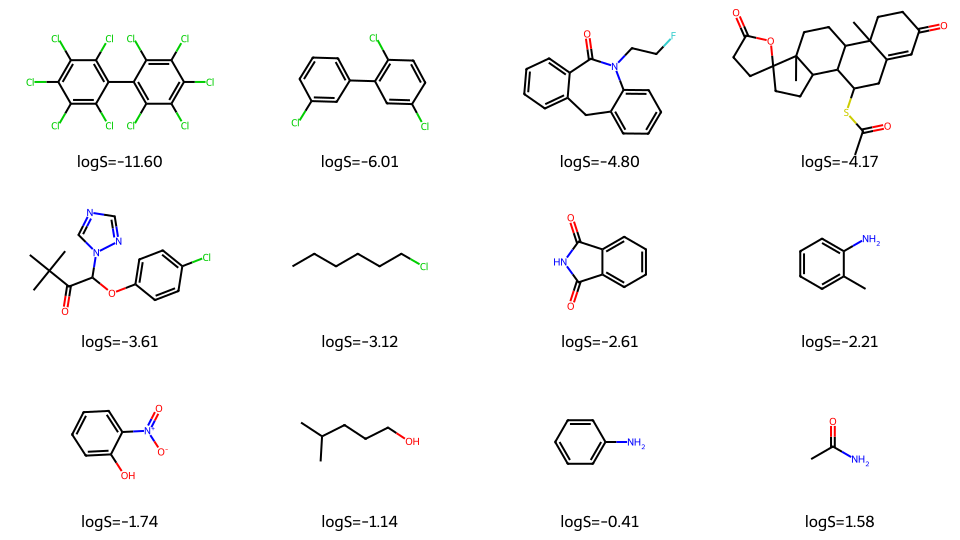

In [4]:
# 대표 분자 12개 — logS 전 구간에서 고르게 뽑아 구조 다양성 확인
from rdkit.Chem import Draw

order = df["logS"].sort_values().index.to_numpy()          # logS 오름차순 정렬
pick12 = order[np.linspace(0, len(order) - 1, 12).astype(int)]  # 전 구간 균등 12개
mols12 = [df["mol"].iloc[i] for i in pick12]
legs12 = [f"logS={df['logS'].iloc[i]:.2f}" for i in pick12]

img_grid = Draw.MolsToGridImage(mols12, legends=legs12, molsPerRow=4,
                                subImgSize=(240, 180))
print("대표 분자 12개 (logS 저 → 고 순, 잘 안 녹음 → 잘 녹음)")
img_grid   # PIL 이미지 → image/png 로 노트북에 임베드

● 물에 가장 안 녹는 6개 (logS 최소) — 대체로 크고 소수성/방향족


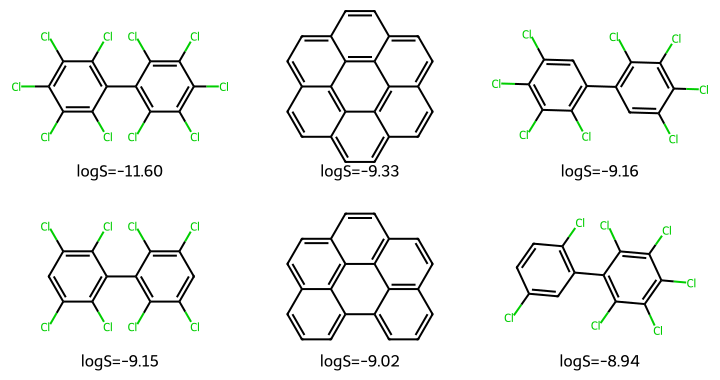

In [5]:
# 용해도 극단 분자 — 가장 잘 녹는 6개 vs 가장 안 녹는 6개
srt = df["logS"].sort_values()
worst_idx = srt.index[:6].to_numpy()      # logS 최소 = 물에 가장 안 녹음
best_idx  = srt.index[-6:][::-1].to_numpy()  # logS 최대 = 물에 가장 잘 녹음

img_worst = Draw.MolsToGridImage(
    [df["mol"].iloc[i] for i in worst_idx],
    legends=[f"logS={df['logS'].iloc[i]:.2f}" for i in worst_idx],
    molsPerRow=3, subImgSize=(240, 190))
print("● 물에 가장 안 녹는 6개 (logS 최소) — 대체로 크고 소수성/방향족")
img_worst

● 물에 가장 잘 녹는 6개 (logS 최대) — 대체로 작고 극성(OH/NH 등)


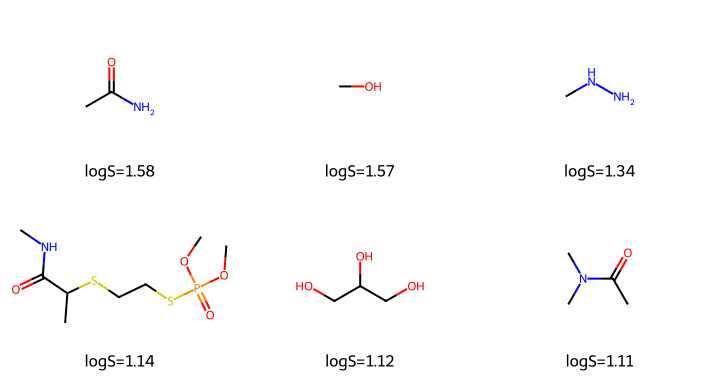

In [6]:
img_best = Draw.MolsToGridImage(
    [df["mol"].iloc[i] for i in best_idx],
    legends=[f"logS={df['logS'].iloc[i]:.2f}" for i in best_idx],
    molsPerRow=3, subImgSize=(240, 190))
print("● 물에 가장 잘 녹는 6개 (logS 최대) — 대체로 작고 극성(OH/NH 등)")
img_best

## 3. 특징 생성 ② — Morgan/ECFP 지문 (radius=2, 2048비트)

각 원자 주변의 원형 부분구조를 해싱해 **2048비트 이진 벡터**로 만듭니다(반경 2 = ECFP4 상당; Rogers & Hahn 2010). 고차원이지만 대부분의 비트가 **거의 항상 0**입니다 → §5·§6에서 통계로 확인하고 필터링합니다.

In [7]:
from rdkit.Chem import rdFingerprintGenerator

mfp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)   # ECFP4 상당
X_fp = np.array([list(mfp.GetFingerprint(m)) for m in df["mol"]], dtype=np.int8)

print("ECFP 행렬:", X_fp.shape)
print("전체 비트 중 1(on)의 평균 비율: %.3f%% → 매우 희소(sparse)" % (100 * X_fp.mean()))
print("분자당 켜진 비트 수: 평균 %.1f개 (2048 중)" % X_fp.sum(axis=1).mean())


ECFP 행렬: (1128, 2048)
전체 비트 중 1(on)의 평균 비율: 1.050% → 매우 희소(sparse)
분자당 켜진 비트 수: 평균 21.5개 (2048 중)


## 4. 특징 분석(EDA) ① — 기술자 분포 & 타깃(logS) 관계

- **분포 히스토그램 그리드**: 각 기술자의 값 범위·치우침(skew)·이상치를 한눈에 봅니다. 왜곡이 큰 특징은 이후 스케일링/변환의 후보가 됩니다.
- **기술자–logS 상관 막대**: 각 기술자가 용해도와 얼마나(어느 방향으로) 관련되는지. logP·MW가 음의 상관(소수성·큰 분자일수록 덜 녹음)을 보이는지 등 화학 직관과 맞는지 확인합니다.

/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1588813701.py:13: UserWarnin

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtoo

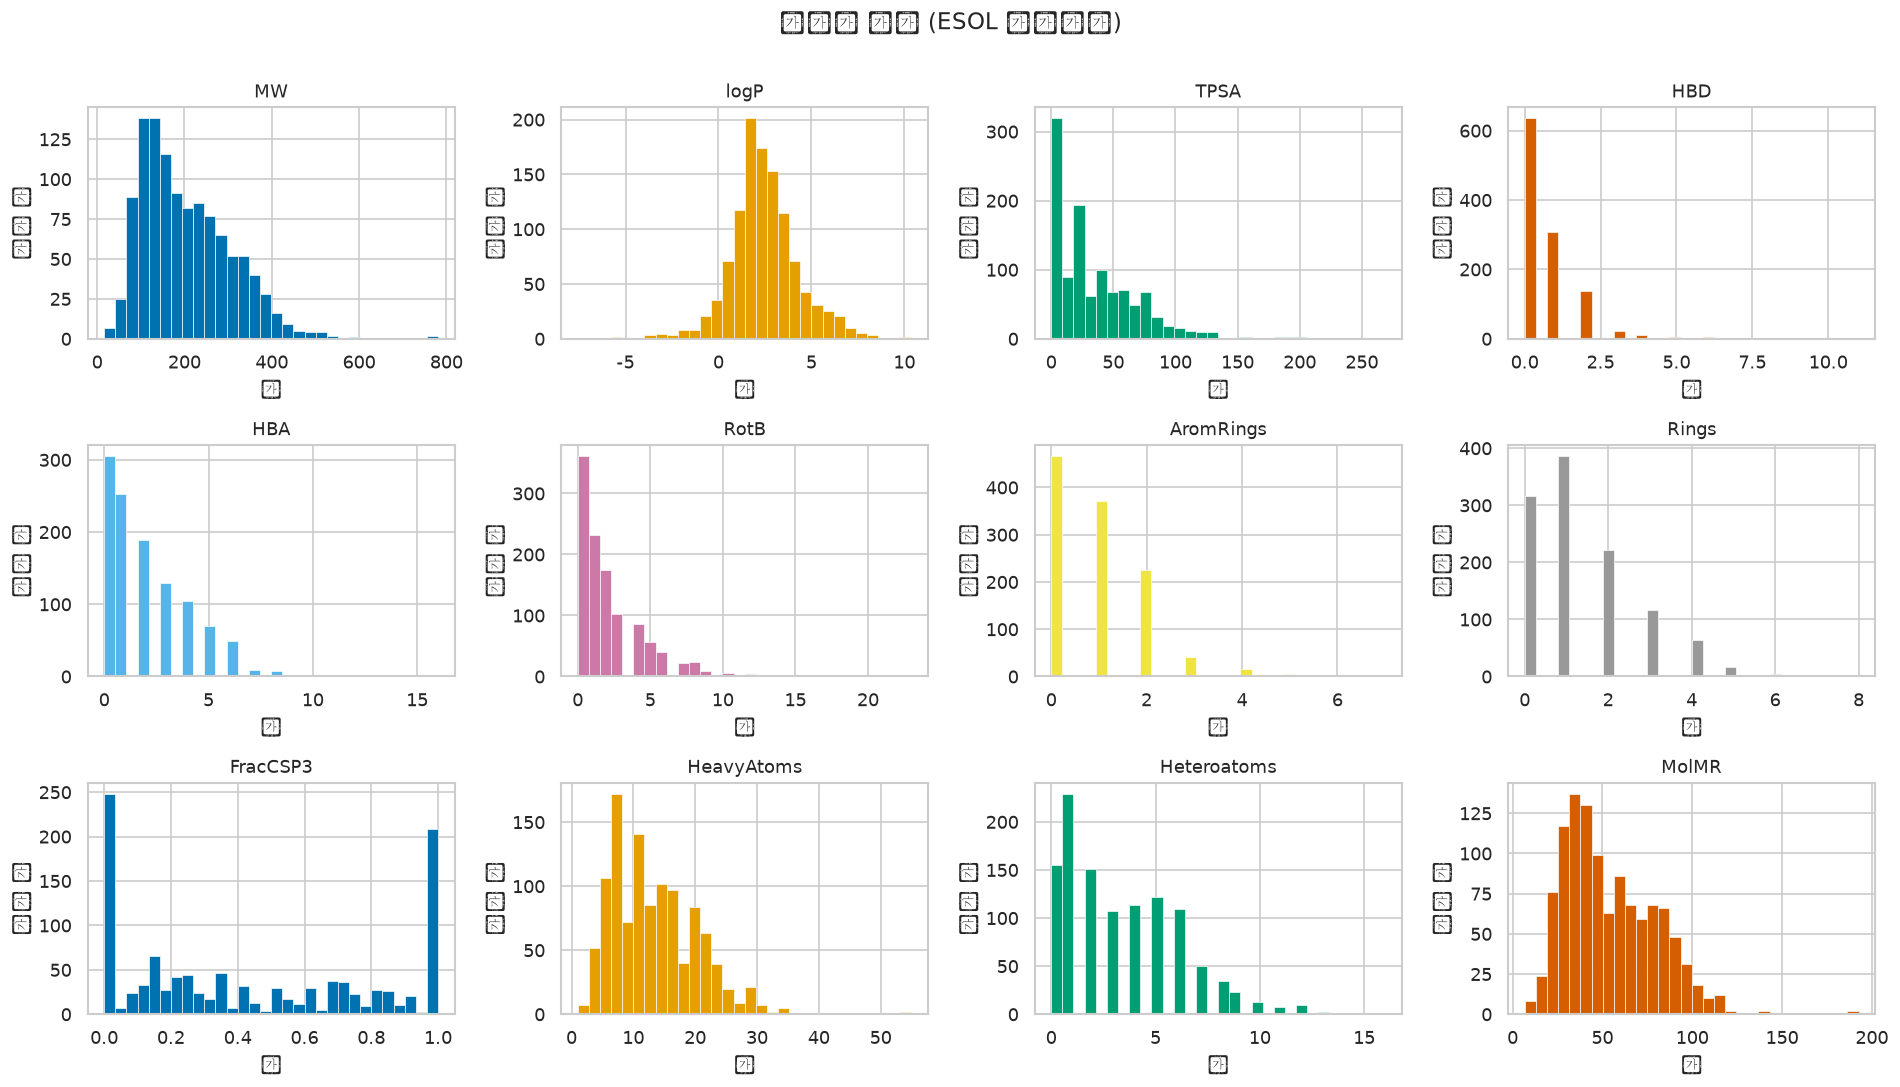

In [8]:
# (1) 기술자 분포 히스토그램 그리드
ncol = 4
nrow = int(np.ceil(len(DESC_NAMES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow))
axes = axes.ravel()
for i, name in enumerate(DESC_NAMES):
    axes[i].hist(desc_df[name], bins=30, color=CB[i % len(CB)], edgecolor="white", linewidth=0.4)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel("값"); axes[i].set_ylabel("분자 수")
for j in range(len(DESC_NAMES), len(axes)):
    axes[j].axis("off")
fig.suptitle("기술자 분포 (ESOL 실데이터)", fontsize=14, y=1.005)
plt.tight_layout(); plt.show()


/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 49832 (\N{HANGUL SYLLABLE SEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/669618900.py:12: UserWarning: G

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylab

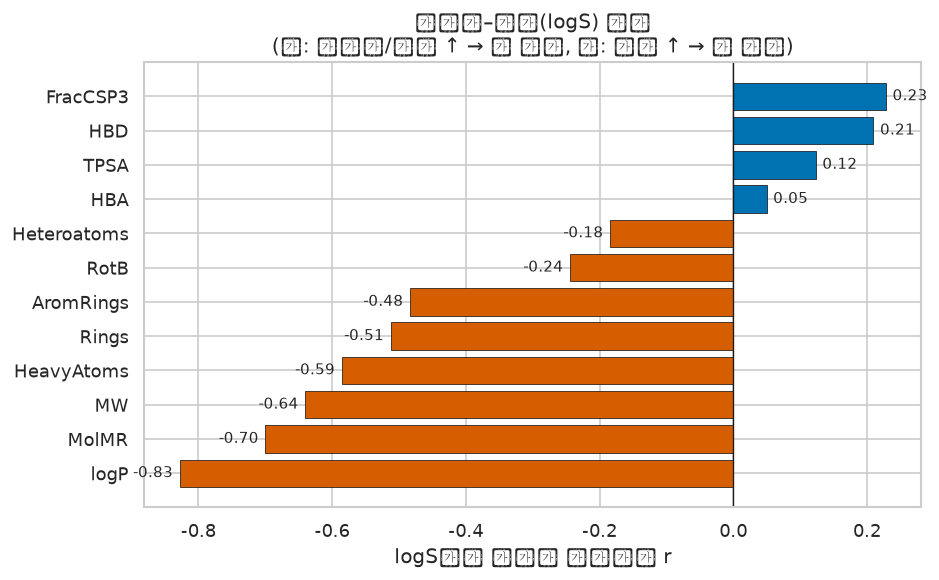

logS와 상관이 가장 강한 기술자 Top 3 (절댓값):
logP     0.828
MolMR    0.700
MW       0.640


In [9]:
# (2) 기술자 vs logS 상관(피어슨) 막대 — 방향/세기
corr_y = desc_df[DESC_NAMES].corrwith(desc_df["logS"]).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#D55E00" if v < 0 else "#0072B2" for v in corr_y.values]  # 음=주황, 양=파랑
ax.barh(corr_y.index, corr_y.values, color=bar_colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("logS와의 피어슨 상관계수 r")
ax.set_title("기술자–타깃(logS) 상관\n(음: 소수성/크기 ↑ → 덜 녹음, 양: 극성 ↑ → 잘 녹음)")
for yi, v in enumerate(corr_y.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), yi, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout(); plt.show()

print("logS와 상관이 가장 강한 기술자 Top 3 (절댓값):")
print(corr_y.abs().sort_values(ascending=False).head(3).round(3).to_string())


/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1940530761.py:16: UserW

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pyla

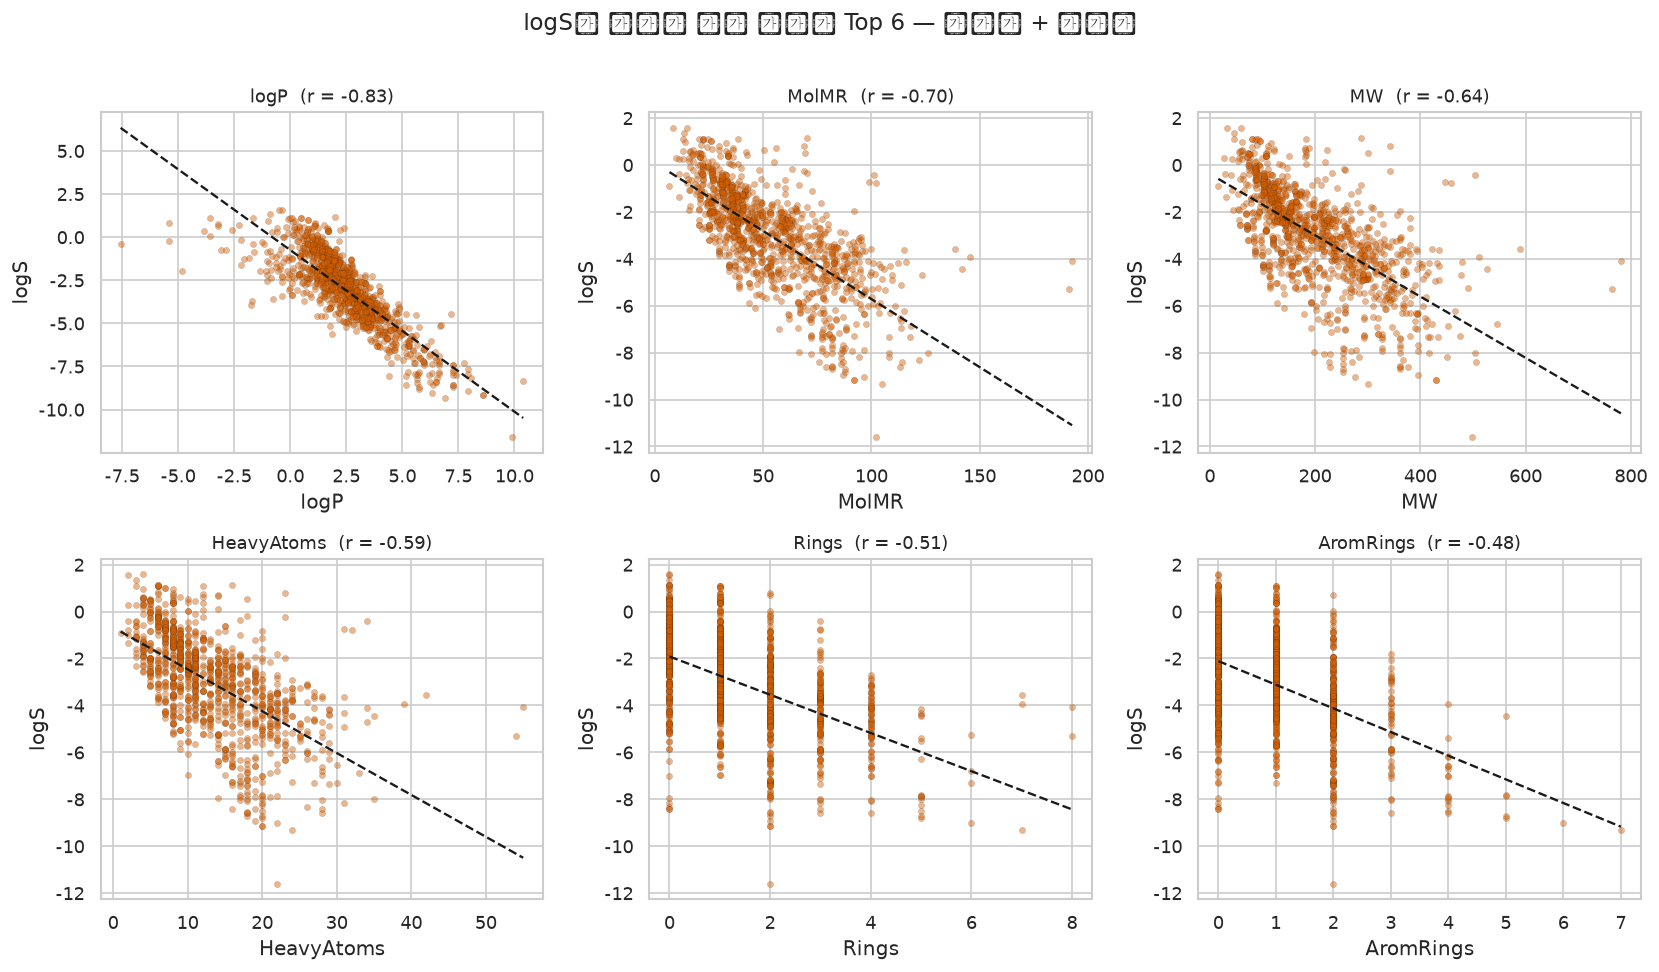

In [10]:
# (2-보강) logS와 상관이 강한 상위 6개 기술자 vs logS 산점도 그리드
top6 = corr_y.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axes.ravel(), top6):
    r = corr_y[name]
    col = "#D55E00" if r < 0 else "#0072B2"
    ax.scatter(desc_df[name], desc_df["logS"], s=14, alpha=0.45,
               color=col, edgecolor="k", linewidth=0.15)
    # 추세선(1차 최소제곱) — 실데이터 기반
    m_, b_ = np.polyfit(desc_df[name], desc_df["logS"], 1)
    xs = np.linspace(desc_df[name].min(), desc_df[name].max(), 50)
    ax.plot(xs, m_ * xs + b_, color="k", lw=1.4, ls="--")
    ax.set_title(f"{name}  (r = {r:+.2f})", fontsize=11)
    ax.set_xlabel(name); ax.set_ylabel("logS")
fig.suptitle("logS와 상관이 강한 기술자 Top 6 — 산점도 + 추세선", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 5. 특징 분석(EDA) ② — 상관 히트맵(공선성) & 화학공간(PCA/UMAP)

- **상관 히트맵**: 기술자들끼리 강하게 겹치는(공선성) 부분을 봅니다. 예를 들어 MW·HeavyAtoms·MolMR은 서로 강한 양의 상관을 가질 수 있습니다 → 필터링/차원축소의 근거.
- **화학공간 투영**: 기술자를 **표준화**한 뒤 PCA(및 가능하면 UMAP)로 **2D**에 투영하고 **logS로 색칠**합니다. 색이 공간에서 매끄럽게 변하면, 이 기술자 표현이 이미 용해도 관련 구조를 담고 있다는 신호입니다.

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49832 (\N{HANGUL SYLLABLE SEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/hjpark/lecture_dru

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtoo

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49832 (\N{HANGUL SYLLABLE SEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabto

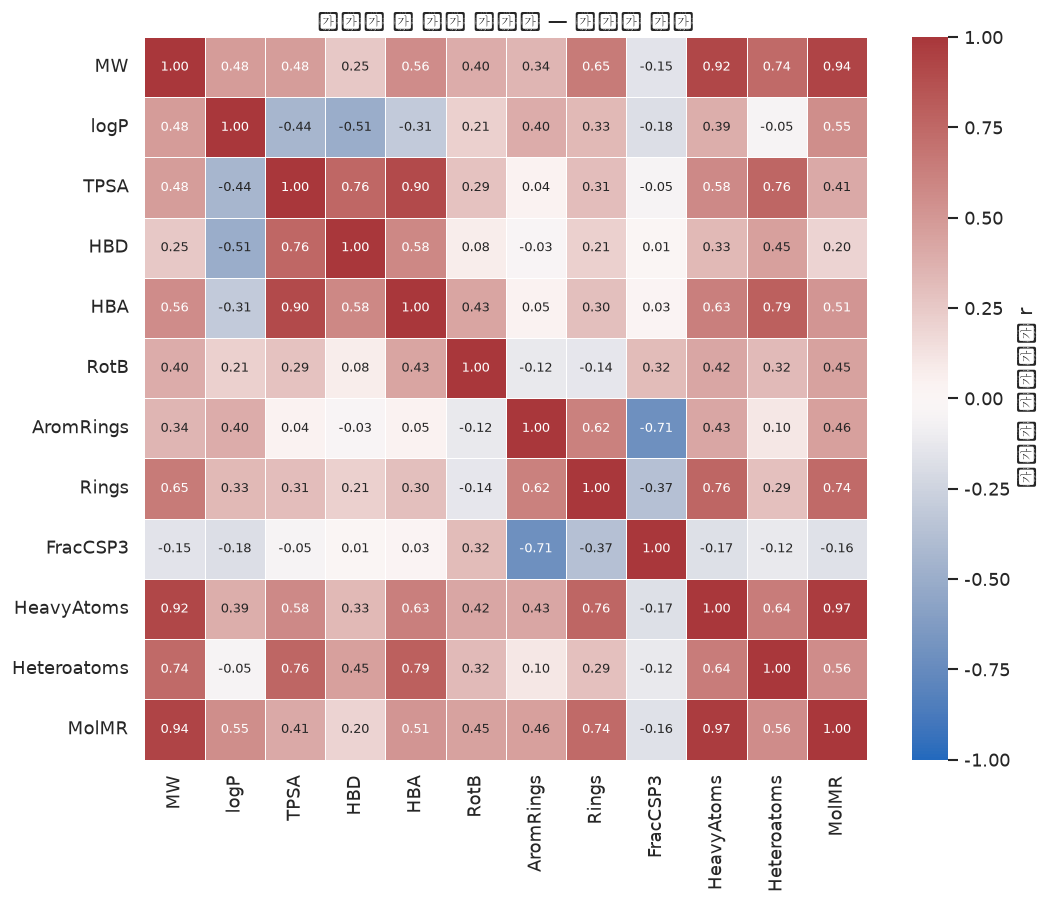

강한 공선성(|r|>0.9) 기술자 쌍:
  HeavyAtoms ~ MolMR: r=0.971
  MW ~ MolMR: r=0.936
  MW ~ HeavyAtoms: r=0.922


In [11]:
# (3) 기술자 상관 히트맵
corr_mat = desc_df[DESC_NAMES].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "피어슨 상관계수 r"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("기술자 간 상관 히트맵 — 공선성 확인")
plt.tight_layout(); plt.show()

# 강한 공선성 쌍(|r|>0.9) 보고
import itertools
pairs = [(a, b, corr_mat.loc[a, b]) for a, b in itertools.combinations(DESC_NAMES, 2)
         if abs(corr_mat.loc[a, b]) > 0.9]
if pairs:
    print("강한 공선성(|r|>0.9) 기술자 쌍:")
    for a, b, r in sorted(pairs, key=lambda t: -abs(t[2])):
        print(f"  {a} ~ {b}: r={r:.3f}")
else:
    print("기술자 사이에 |r|>0.9 쌍은 없습니다.")


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/2110119365.py:27: UserW

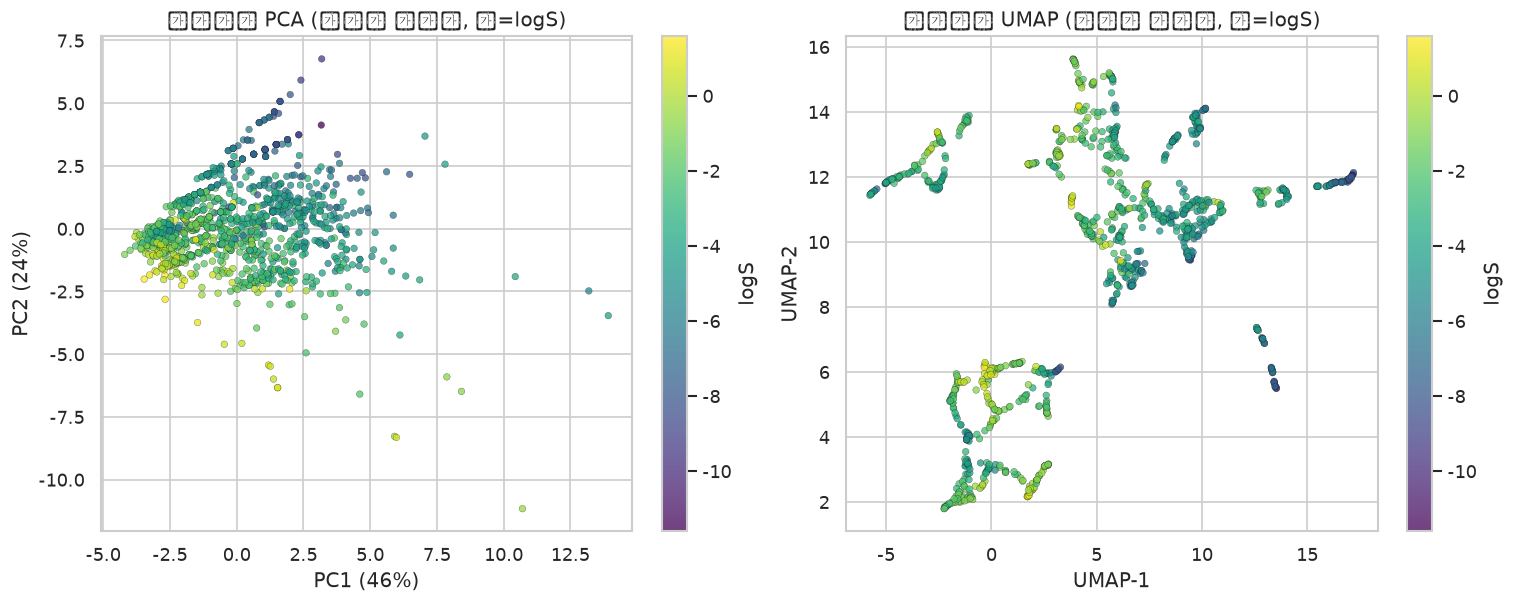

In [12]:
# (4) 화학공간 2D 투영 — 표준화 후 PCA (+ 가능하면 UMAP), 색=logS
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xd_std = StandardScaler().fit_transform(X_desc)          # 표준화(기술자 스케일 상이)

pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(Xd_std)
evr = pca.explained_variance_ratio_
proj = [("PCA", emb_pca, f"PC1 ({evr[0]*100:.0f}%)", f"PC2 ({evr[1]*100:.0f}%)")]

# UMAP은 있으면 사용(비선형 구조), 없으면 PCA만
try:
    from umap import UMAP
    emb_umap = UMAP(n_components=2, random_state=42).fit_transform(Xd_std)
    proj.append(("UMAP", emb_umap, "UMAP-1", "UMAP-2"))
except Exception as e:
    print("UMAP 미설치/미사용 → PCA만 표시 (%s)" % type(e).__name__)

fig, axes = plt.subplots(1, len(proj), figsize=(6.4 * len(proj), 5.2), squeeze=False)
for ax, (title, emb, xl, yl) in zip(axes[0], proj):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="viridis", s=16, alpha=0.75,
                    edgecolor="k", linewidth=0.2)
    ax.set_title(f"화학공간 {title} (기술자 표준화, 색=logS)")
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    plt.colorbar(sc, ax=ax, fraction=0.046, label="logS")
plt.tight_layout(); plt.show()


### 화학공간의 위치 ↔ 실제 구조 연결

PCA 산점도에서 **극단(모서리) 위치**에 있는 분자들이 실제로 어떤 구조인지 확인합니다. 화학공간의 축이 구조/물성의 어떤 축과 대응하는지 직관적으로 이해할 수 있습니다.

/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/1537294725.py:22: Use

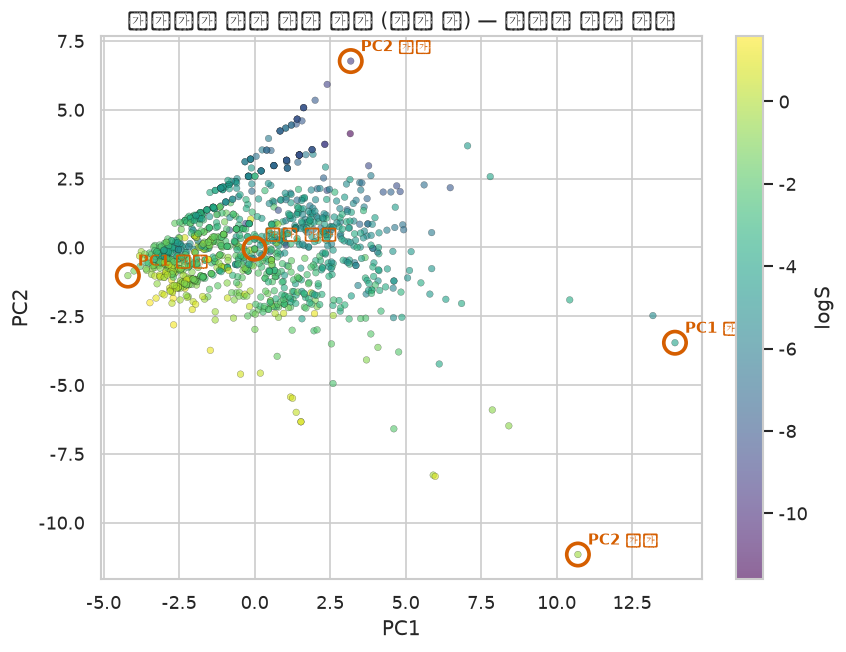

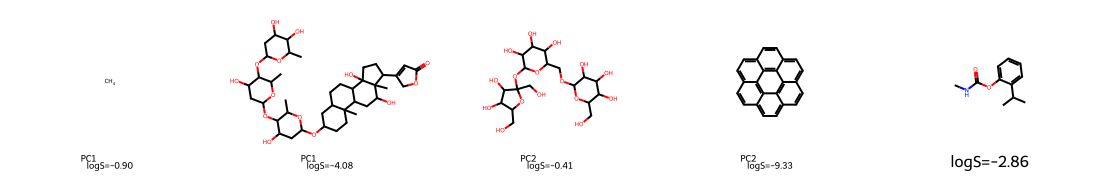

In [13]:
# PCA 4개 모서리(+중심) 근처 분자를 골라 구조와 함께 표시
pc1, pc2 = emb_pca[:, 0], emb_pca[:, 1]
corners = {
    "PC1 최소": int(np.argmin(pc1)),
    "PC1 최대": int(np.argmax(pc1)),
    "PC2 최소": int(np.argmin(pc2)),
    "PC2 최대": int(np.argmax(pc2)),
    "중심 근처": int(np.argmin(pc1**2 + pc2**2)),
}
# 산점도에 위치 표시
fig, ax = plt.subplots(figsize=(7.2, 5.6))
sc = ax.scatter(pc1, pc2, c=y, cmap="viridis", s=16, alpha=0.6,
                edgecolor="k", linewidth=0.2)
for lab, i in corners.items():
    ax.scatter(pc1[i], pc2[i], s=180, facecolor="none",
               edgecolor="#D55E00", linewidth=2.2, zorder=5)
    ax.annotate(lab, (pc1[i], pc2[i]), fontsize=9, fontweight="bold",
                xytext=(6, 6), textcoords="offset points", color="#D55E00")
plt.colorbar(sc, ax=ax, fraction=0.046, label="logS")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("화학공간 극단 위치 분자 (주황 원) — 아래에 구조 표시")
plt.tight_layout(); plt.show()

# 해당 분자들의 실제 구조
cidx = list(corners.values())
img_corner = Draw.MolsToGridImage(
    [df["mol"].iloc[i] for i in cidx],
    legends=[f"{lab}\nlogS={df['logS'].iloc[i]:.2f}"
             for lab, i in corners.items()],
    molsPerRow=5, subImgSize=(220, 180))
img_corner

## 6. 특징 분석(EDA) ③ — ECFP 비트 통계 (희소성)

2048비트 각각이 **몇 %의 분자에서 켜지는지**(on-bit 빈도)를 봅니다. 대부분의 비트는 거의 항상 0이라 정보가 없고(상수에 가까움), 일부만 자주 등장합니다. 이 **희소성**이 §7 필터링의 직접적 근거입니다.

/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWa

/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3574152684.py:20: UserW

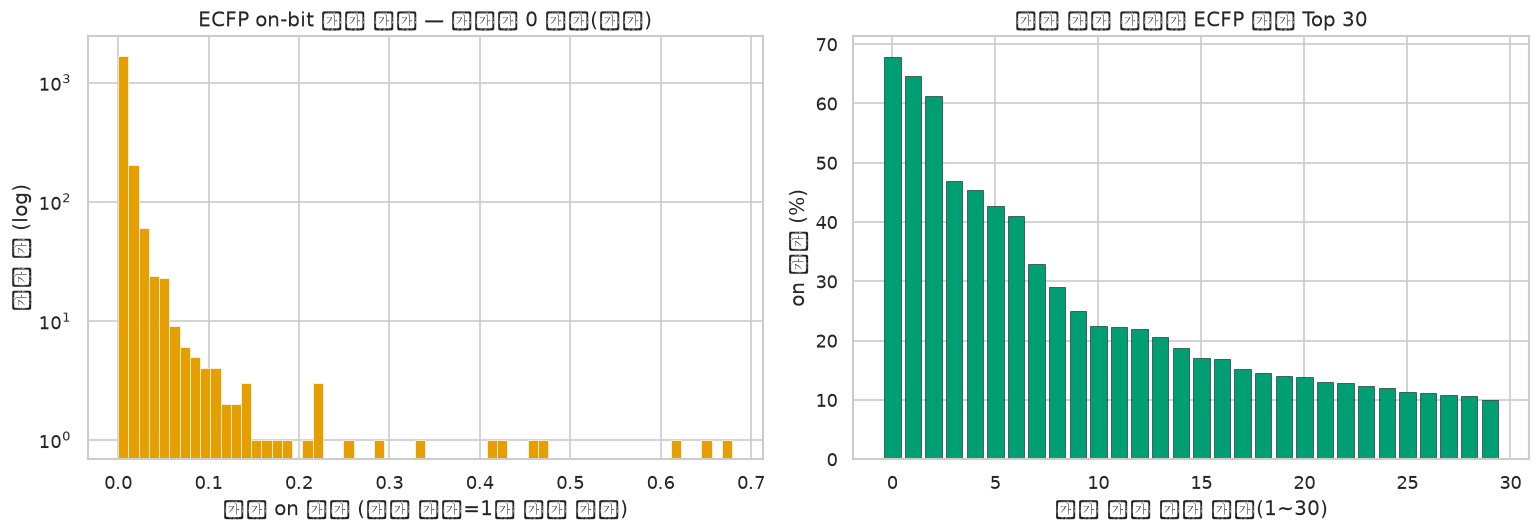

한 번도 켜지지 않은 비트: 192 / 2048 (9.4%)
1% 미만 분자에서만 켜지는 희소 비트: 1660 / 2048 (81.1%)
→ 대부분의 비트는 거의 상수(0). 저분산 필터로 걸러낼 대상입니다.


In [14]:
# 비트별 on 빈도(= 각 비트가 1인 분자 비율)
bit_freq = X_fp.mean(axis=0)          # 길이 2048
n_dead = int((bit_freq == 0).sum())   # 한 번도 켜지지 않은 비트
n_rare = int((bit_freq < 0.01).sum()) # 1% 미만 분자에서만 켜지는 비트

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# (좌) on-bit 빈도 히스토그램(로그 y) — 대부분 0 근처
axes[0].hist(bit_freq, bins=60, color="#E69F00", edgecolor="white", linewidth=0.4)
axes[0].set_yscale("log")
axes[0].set_xlabel("비트 on 빈도 (해당 비트=1인 분자 비율)")
axes[0].set_ylabel("비트 수 (log)")
axes[0].set_title("ECFP on-bit 빈도 분포 — 대부분 0 근처(희소)")

# (우) 상위 빈출 비트 30개 막대
top = np.argsort(bit_freq)[::-1][:30]
axes[1].bar(range(30), bit_freq[top] * 100, color="#009E73", edgecolor="black", linewidth=0.3)
axes[1].set_xlabel("빈출 상위 비트 순위(1~30)")
axes[1].set_ylabel("on 빈도 (%)")
axes[1].set_title("가장 자주 켜지는 ECFP 비트 Top 30")
plt.tight_layout(); plt.show()

print(f"한 번도 켜지지 않은 비트: {n_dead} / 2048 ({100*n_dead/2048:.1f}%)")
print(f"1% 미만 분자에서만 켜지는 희소 비트: {n_rare} / 2048 ({100*n_rare/2048:.1f}%)")
print("→ 대부분의 비트는 거의 상수(0). 저분산 필터로 걸러낼 대상입니다.")


### ECFP 비트가 실제로 가리키는 부분구조

ECFP 비트는 각각 특정 **원자 환경(부분구조)** 을 뜻합니다. 자주 켜지는 빈출 비트 몇 개가 어떤 부분구조에 대응하는지 `Draw.DrawMorganBit` 으로 시각화합니다 (파란 원=중심 원자, 회색=반경 내 이웃).

빈출 ECFP 비트 → 대응 부분구조 (파란 원=중심 원자)


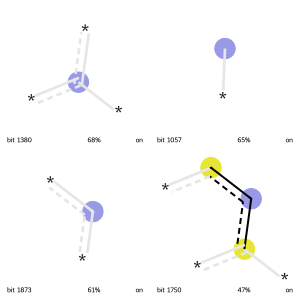

In [15]:
# 빈출 상위 비트 → 그 비트를 켜는 실제 분자의 부분구조 렌더
from rdkit.Chem import AllChem
from IPython.display import Image as IPImage, SVG, display

top_bits = np.argsort(bit_freq)[::-1][:6]   # 가장 자주 켜지는 비트 후보
examples = []                                # (mol, bitId, bitInfo, freq)
for b in top_bits:
    b = int(b)
    for m in df["mol"]:                      # 해당 비트를 켜는 첫 분자 탐색
        bi = {}
        AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048, bitInfo=bi)
        if b in bi:
            examples.append((m, b, bi, bit_freq[b]))
            break
    if len(examples) >= 4:                    # 4개면 충분
        break

try:
    out = Draw.DrawMorganBits(
        [(m, b, bi) for (m, b, bi, f) in examples],
        molsPerRow=2,
        legends=[f"bit {b} — 분자 {f*100:.0f}%에서 on" for (m, b, bi, f) in examples],
        useSVG=False)
    print("빈출 ECFP 비트 → 대응 부분구조 (파란 원=중심 원자)")
    # 반환형이 rdkit 버전에 따라 bytes / PIL.Image / SVG(str) 로 다름 → 모두 대응
    if isinstance(out, (bytes, bytearray)):
        display(IPImage(data=bytes(out)))
    elif isinstance(out, str):
        display(SVG(out))
    else:                                    # PIL.Image 등 _repr_png_ 보유 객체
        display(out)
except Exception as e:
    print("부분구조 렌더 생략:", type(e).__name__, e)

## 6-1. (선택) Lipinski 물성 요약

경구 약물유사성의 관례적 기준인 **Lipinski's Rule of Five**(MW≤500, logP≤5, HBD≤5, HBA≤10)를 얼마나 위반하는지 요약합니다. 특징(물성) 관점에서 데이터셋 분자들의 '약물스러움' 분포를 파악하는 용도입니다.

Lipinski Rule of Five — 위반 개수 분포:
0    1018
1      98
2      10
3       2

위반 0개(모두 만족) 분자: 1018 / 1128 (90.2%)


/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 52825 (\N{HANGUL SYLLABLE CIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3346553704.py:20: UserWar

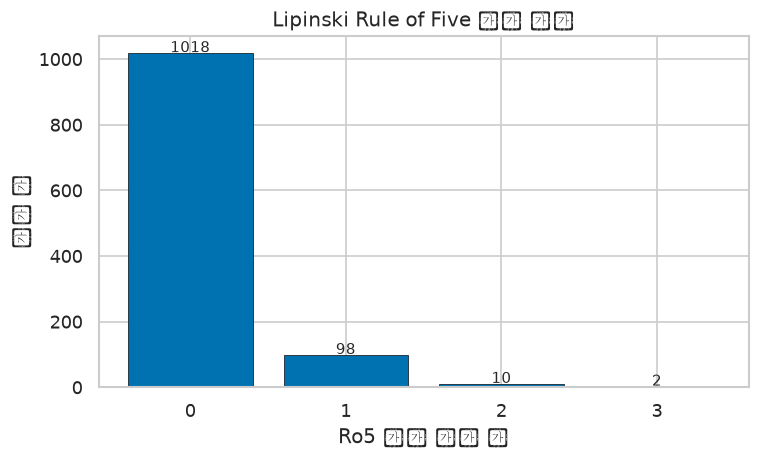

In [16]:
ro5 = pd.DataFrame({
    "MW>500":  desc_df["MW"]  > 500,
    "logP>5":  desc_df["logP"] > 5,
    "HBD>5":   desc_df["HBD"] > 5,
    "HBA>10":  desc_df["HBA"] > 10,
})
violations = ro5.sum(axis=1)
print("Lipinski Rule of Five — 위반 개수 분포:")
print(violations.value_counts().sort_index().rename("분자 수").to_string())
print(f"\n위반 0개(모두 만족) 분자: {int((violations == 0).sum())} / {len(df)} "
      f"({100*(violations == 0).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(6.5, 4))
vc = violations.value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color="#0072B2", edgecolor="black", linewidth=0.4)
ax.set_xlabel("Ro5 위반 규칙 수"); ax.set_ylabel("분자 수")
ax.set_title("Lipinski Rule of Five 위반 분포")
for xi, v in zip(vc.index.astype(str), vc.values):
    ax.text(xi, v + 3, str(v), ha="center", fontsize=9)
plt.tight_layout(); plt.show()


## 7. 특징 필터링 — ECFP 지문 다이어트 (train에서만 학습)

§6에서 확인한 희소성/중복을 실제로 제거합니다. **핵심 원칙: 필터는 train에서만 학습**해 test에 적용합니다(테스트 정보가 특징 선택에 새어들면 성능이 부풀려집니다 = 데이터 누수). 여기서는 모델을 학습하지 않지만, 특징 선택 자체도 train 기준으로 하는 습관을 그대로 보여 줍니다.

1. **저분산 필터** `VarianceThreshold(threshold=0.01)` — 이진 비트의 분산은 `p(1-p)`. 임계 0.01은 대략 `p<1%` 또는 `p>99%`인 **거의 상수 비트**를 제거합니다.
2. **공선성 필터** — 남은 비트들의 상관행렬 **상삼각**에서 `|r|>0.9`인 쌍은 정보가 중복되므로 한쪽 열을 드롭합니다.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

# train/test 분할 — 필터 '학습'은 train에서만(누수 방지). (모델 학습은 없음)
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)
Xtr_fp, Xte_fp = X_fp[idx_tr].astype(float), X_fp[idx_te].astype(float)
print("train:", len(idx_tr), "| test:", len(idx_te))

# (1) 저분산 필터 — train에서만 fit
vt = VarianceThreshold(threshold=0.01).fit(Xtr_fp)
Xtr_v, Xte_v = vt.transform(Xtr_fp), vt.transform(Xte_fp)
d_raw, d_var = X_fp.shape[1], Xtr_v.shape[1]
print(f"[저분산] {d_raw} → {d_var} 비트 ({d_raw - d_var}개 제거, 거의 상수 비트)")

# (2) 공선성 필터 — train 상관행렬 상삼각 |r|>0.9 열 드롭
corr = np.abs(np.corrcoef(Xtr_v, rowvar=False))
corr = np.nan_to_num(corr)                # 혹시 남은 상수열 방어
upper = np.triu(corr, k=1)                # 상삼각(대각 제외)
drop_mask = (upper > 0.9).any(axis=0)     # 앞선 어떤 열과 |r|>0.9면 드롭
keep = ~drop_mask
Xtr_filt, Xte_filt = Xtr_v[:, keep], Xte_v[:, keep]
d_filt = Xtr_filt.shape[1]
print(f"[공선성] {d_var} → {d_filt} 비트 ({int(drop_mask.sum())}개 제거, |r|>0.9 중복)")
print(f"=> 최종: ECFP raw {d_raw} → filtered {d_filt} "
      f"({100 * (1 - d_filt / d_raw):.1f}% 축소)")


train: 902 | test: 226


[저분산] 2048 → 375 비트 (1673개 제거, 거의 상수 비트)
[공선성] 375 → 368 비트 (7개 제거, |r|>0.9 중복)
=> 최종: ECFP raw 2048 → filtered 368 (82.0% 축소)


/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2936651/3915570333.py:10: UserWa

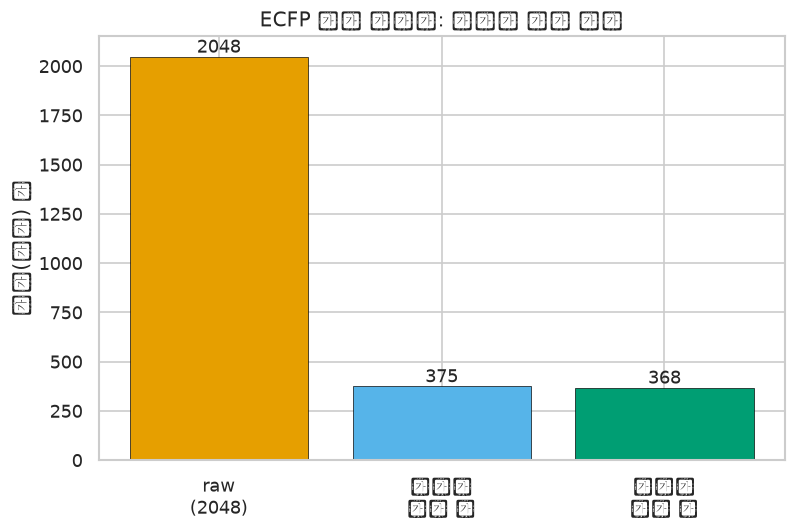

=== 특징 필터링 요약(실측) ===


,단계,차원,누적 제거,raw 대비 축소율(%)
0,ECFP raw,2048,0,0.0
1,저분산 필터 후,375,1673,81.7
2,공선성 필터 후,368,1680,82.0


In [18]:
# 필터링 단계별 차원 축소 막대
stages = ["raw\n(2048)", "저분산\n필터 후", "공선성\n필터 후"]
dvals = [d_raw, d_var, d_filt]
fig, ax = plt.subplots(figsize=(6.8, 4.6))
bars = ax.bar(stages, dvals, color=["#E69F00", "#56B4E9", "#009E73"],
              edgecolor="black", linewidth=0.4)
ax.set_ylabel("특징(비트) 수"); ax.set_title("ECFP 특징 필터링: 단계별 차원 축소")
for b, v in zip(bars, dvals):
    ax.text(b.get_x() + b.get_width() / 2, v + 20, str(v), ha="center", fontsize=11)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "단계": ["ECFP raw", "저분산 필터 후", "공선성 필터 후"],
    "차원": [d_raw, d_var, d_filt],
    "누적 제거": [0, d_raw - d_var, d_raw - d_filt],
    "raw 대비 축소율(%)": [0.0, round(100*(1-d_var/d_raw), 1), round(100*(1-d_filt/d_raw), 1)],
})
print("=== 특징 필터링 요약(실측) ===")
summary


## 8. 정리 — 좋은 특징이 모델링의 출발점

- **특징 생성**: 같은 분자라도 표현이 다릅니다. **기술자**(해석 가능·저차원)와 **ECFP 지문**(고차원·희소)을 모두 만들어 두면 이후 모델링 선택지가 넓어집니다.
- **특징 분석(EDA)**: 분포·타깃 상관·공선성 히트맵·화학공간 투영·ECFP 비트 통계를 통해 특징이 **무엇을 담고 있고, 어디가 중복/무의미한지**를 눈으로 확인했습니다. 이 이해가 없으면 필터링과 모델 선택이 근거 없는 추측이 됩니다.
- **특징 필터링**: 저분산+공선성 필터로 ECFP 차원을 크게 줄였습니다(위 표 실측). 필터는 **train에서만 학습**해 누수를 막았습니다 — 이 습관이 모델링 단계에서 정직한 성능 평가로 이어집니다.

> ⚠️ 교육용 데모입니다. 모든 통계·그림은 이 노트북이 ESOL 실데이터로 실제 계산한 값이며, `logS`는 특징을 이해하기 위한 분석 대상으로만 사용했습니다(모델 학습 없음).

**좋은 특징을 만들고 이해하는 것이 모델링의 출발점입니다 — 다음 [02 노트북]에서는 여기서 만든 특징(기술자·ECFP filtered·ChemBERTa 임베딩)으로 실제 QSAR 회귀 모델을 학습하고 성능을 비교합니다.**

**참고문헌 (실재)**
- Delaney. *ESOL: Estimating Aqueous Solubility Directly from Molecular Structure.* J Chem Inf Comput Sci 44:1000–1005 (2004).
- Rogers & Hahn. *Extended-Connectivity Fingerprints.* J Chem Inf Model 50:742–754 (2010).
- Todeschini & Consonni. *Handbook of Molecular Descriptors.* Wiley-VCH (2000).
- RDKit: Open-source cheminformatics (https://www.rdkit.org)